## E-Commerce Sales Analysis Dashboard

**Objective**

Analyze an e-commerce sales dataset and create a dashboard using Matplotlib to answer business questions.

Dataset Columns:

- order_id
- order_date
- customer_id
- product_category
- region
- quantity
- unit_price
- discount
- payment_method
- delivery_days
- customer_rating
- revenue



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/ecommerce_sales.csv")

df["order_date"] = pd.to_datetime(df["order_date"])
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month_name()
df["month"] = pd.Categorical(
    df["month"],
    categories=[
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December",
    ],
)
# pd.categorical helps ensure the months are plotted in the correct chronological order

C:\Users\User\AppData\Local\Temp\ipykernel_8944\3246111503.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby("month")["revenue"].sum()


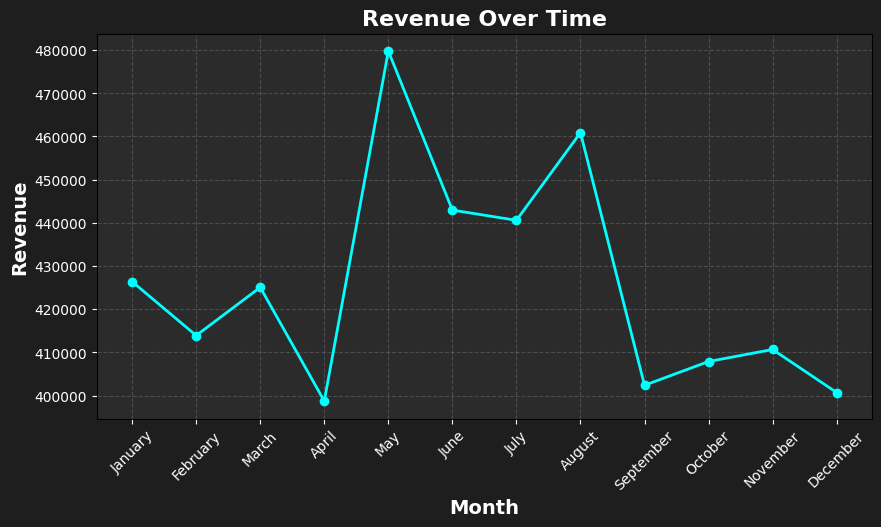

In [2]:
# 1. Line Plot for Revenue Over Months
# Question: How has the revenue changed over the months?

monthly_sales = df.groupby("month")["revenue"].sum()
# monthly_sales.index means names of the months, which will be plotted on the x-axis of the graph.
# monthly_sales.values means respective revenue values for each month, which will be plotted on the y-axis of the graph.

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")


plt.plot(
    monthly_sales.index, monthly_sales.values, marker="o", color="cyan", linewidth=2
)

plt.title("Revenue Over Time", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Month", fontsize=14, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=14, fontweight="bold", color="white")
plt.xticks(rotation=45)
plt.tick_params(axis="both", colors="white")
plt.grid(linestyle="--", alpha=0.25)
plt.savefig("outputs/Revenue_Over_Months.png", dpi=300, bbox_inches="tight")
plt.show()

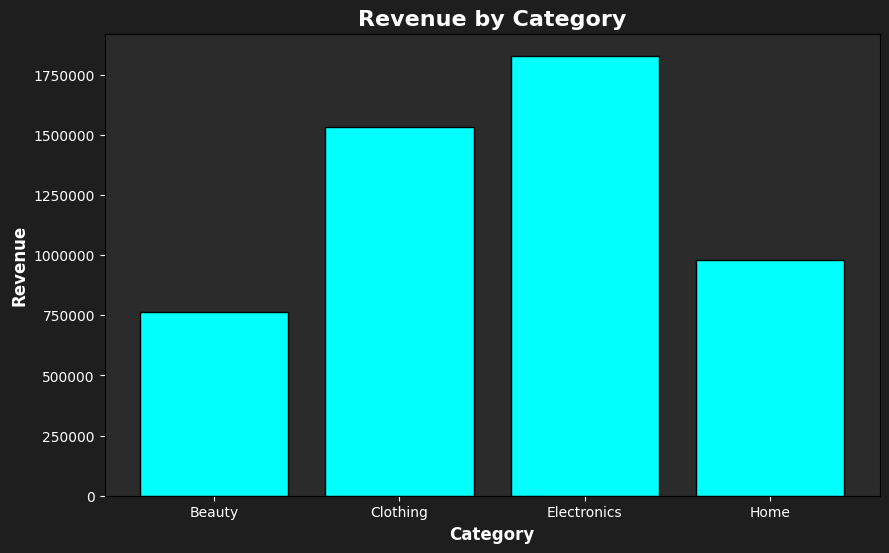

In [3]:
# 2. Bar Plot for Revenue by Product Category
# Question: What is the total revenue generated by each product category?
cat_sales = df.groupby("product_category")["revenue"].sum()

fig = plt.figure(figsize=(10, 6))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

plt.bar(cat_sales.index, cat_sales.values, color="cyan", edgecolor="black")

plt.title("Revenue by Category", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Category", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=12, fontweight="bold", color="white")
plt.ticklabel_format(style="plain", axis="y")  # to remove 1e6 format on y axis
plt.tick_params(axis="both", colors="white")
plt.savefig("outputs/Revenue_by_Product_Category.png", dpi=300, bbox_inches="tight")
plt.show()

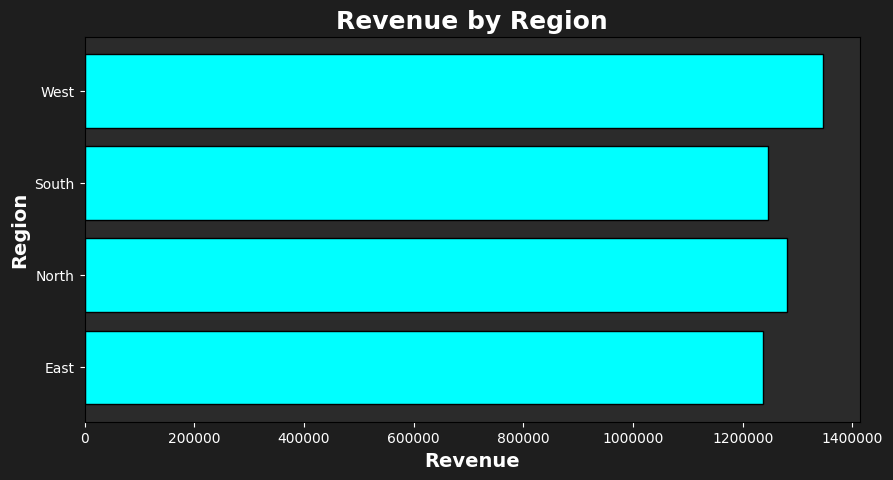

In [4]:
# 3. Horizontal Bar Plot for Revenue by Region
# Question: Which region has generated the highest revenue?

region_sales = df.groupby("region")["revenue"].sum()

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

plt.barh(region_sales.index, region_sales.values, color="cyan", edgecolor="black")

plt.title("Revenue by Region", fontsize=18, fontweight="bold", color="white")
plt.xlabel("Revenue", fontsize=14, fontweight="bold", color="white")
plt.ylabel("Region", fontsize=14, fontweight="bold", color="white")
# plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="x")  # to remove 1e6 format on x axis
plt.tick_params(axis="both", colors="white")
plt.savefig("outputs/Revenue_by_Region.png", dpi=300, bbox_inches="tight")
plt.show()

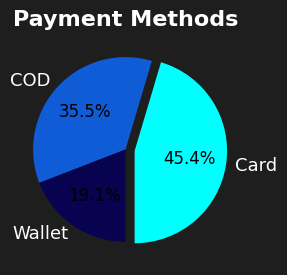

In [5]:
# 4. Pie Chart: payment methods
# Question: What is the distribution of payment methods used by customers?
payments = df["payment_method"].value_counts()

fig = plt.figure(figsize=(20, 3))  # Create a new figure
fig.patch.set_facecolor(
    "#1e1e1e"
)  # Set the background color of the figure to a dark shade
ax = plt.gca()  # Get the current axes of the figure
ax.set_facecolor(
    "#2b2b2b"
)  # Set the background color of the axes to a slightly lighter dark shade

colors = ["cyan", "#1060E2F1", "#080350"]

wedges, texts, autotexts = (
    ax.pie(  # Create a pie chart , wedges are the slices of the pie, texts are the labels, and autotexts are the percentage values
        payments,
        labels=payments.index,
        autopct="%1.1f%%",
        colors=colors,
        startangle=270,
        explode=(0.1, 0, 0),
    )
)
# make legend white
for text in texts:
    text.set_color("white")
    text.set_fontsize(13)

# Make percentages black
for autotext in autotexts:
    autotext.set_color("black")
    autotext.set_fontsize(12)

plt.title("Payment Methods", color="white", fontsize=16, fontweight="bold")

plt.savefig("outputs/Payment_Methods.png", dpi=300, bbox_inches="tight")
plt.show()

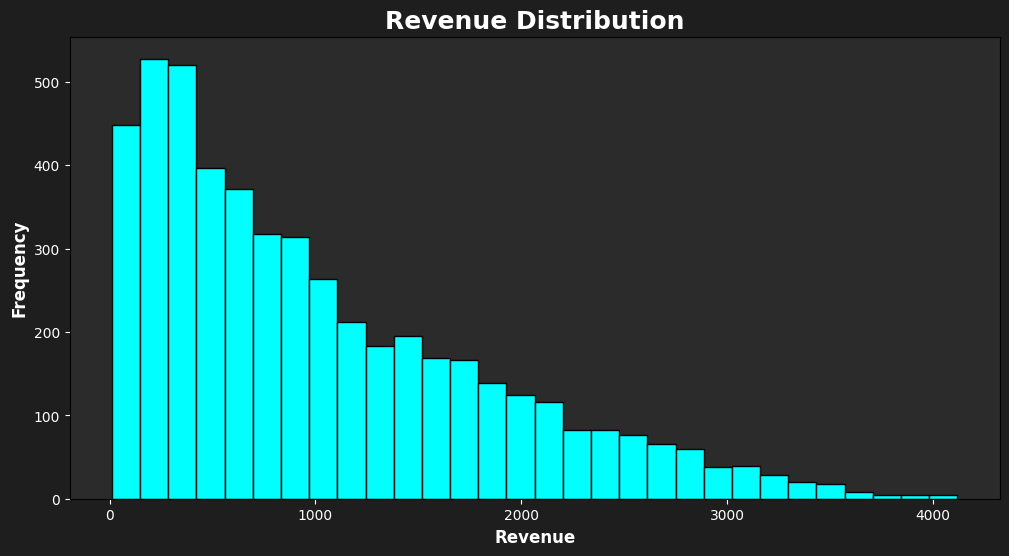

In [6]:
# 5. Histogram: Revenue Distribution
# Question: What is the distribution of revenue across all orders?

fig = plt.figure(figsize=(12, 6))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

plt.hist(df["revenue"], bins=30, color="cyan", edgecolor="black")
plt.tick_params(axis="both", colors="white")
plt.title("Revenue Distribution", fontsize=18, fontweight="bold", color="white")
plt.xlabel("Revenue", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Frequency", fontsize=12, fontweight="bold", color="white")

plt.savefig("outputs/Revenue_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8944\2699621591.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


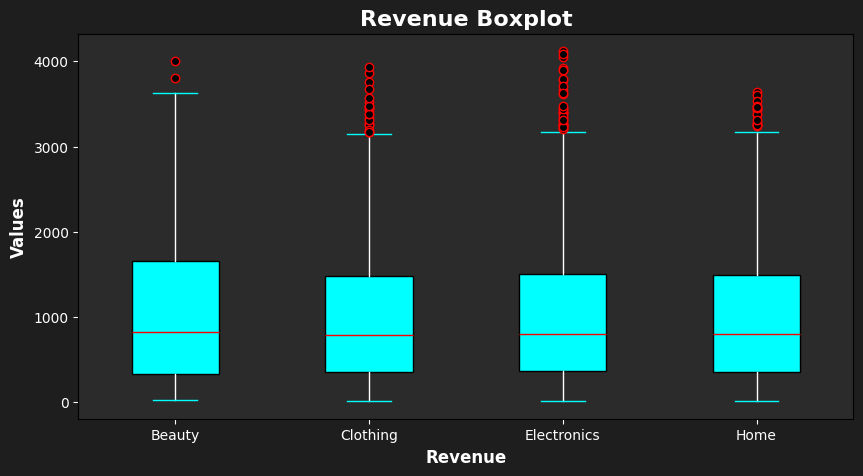

In [7]:
# 6. Box Plot : to detect outliers
# Question: Are there any outliers in the revenue data?

groups = []
for c in df["product_category"].unique():
    groups.append(
        df[df["product_category"] == c]["revenue"]
    )  # grouping revenue data by product category to create a list of revenue values for each category

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

plt.boxplot(
    groups,
    labels=df["product_category"].unique(),
    medianprops=dict(color="red"),
    patch_artist=True,
    boxprops=dict(facecolor="cyan", color="black"),
    whiskerprops=dict(color="white"),
    capprops=dict(color="cyan"),
    flierprops=dict(markerfacecolor="black", markeredgecolor="red"),
)

# medianprops=dict(color="red") sets the color of the median line to red,
# patch_artist=True allows the box to be filled with color,
# boxprops=dict(facecolor="cyan", color="cyan") sets the color of the box to cyan,
# whiskerprops=dict(color="cyan") sets the color of the whiskers to cyan,
# capprops=dict(color="cyan") sets the color of the caps to cyan,
# flierprops=dict(markerfacecolor="black", markeredgecolor="red") sets the color of the outliers to black with red edges.

plt.tick_params(axis="both", colors="white")
plt.title("Revenue Boxplot", color="white", fontsize=16, fontweight="bold")
plt.xlabel("Revenue", color="white", fontsize=12, fontweight="bold")
plt.ylabel("Values", color="white", fontsize=12, fontweight="bold")

plt.savefig("outputs/Revenue_Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

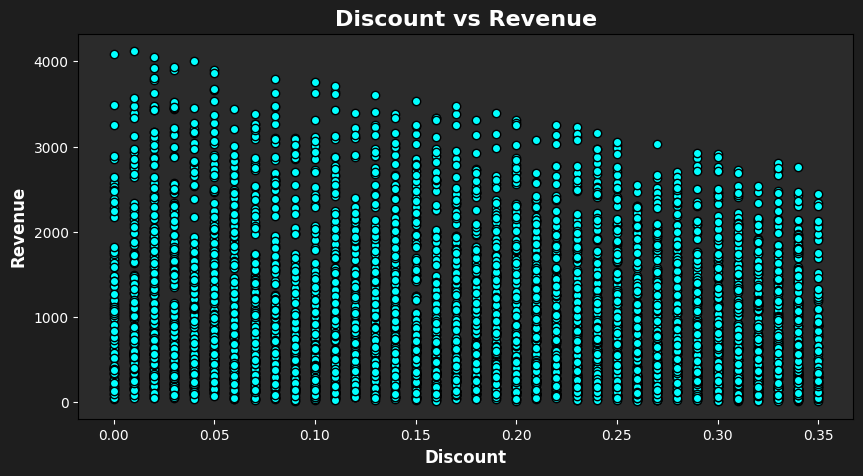

In [8]:
# 7. Scatter Plot: Revenue vs. Quantity
# Question: Is there a relationship between the quantity of products sold and the revenue generated?


fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

plt.scatter(df["discount"], df["revenue"], color="cyan", edgecolor="black")

plt.xlabel("Discount", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=12, fontweight="bold", color="white")
plt.title("Discount vs Revenue", fontsize=16, fontweight="bold", color="white")
plt.tick_params(axis="both", colors="white")

plt.savefig("outputs/Discount_Vs_Revenue.png", dpi=300, bbox_inches="tight")
plt.show()
# plot shows a positive correlation between discount and revenue , this means that as the discount increases, the revenue also increases. This could be due to the fact that customers are more likely to purchase products when they are offered at a discount, leading to an increase in revenue.
# positive can be detrmined seeing this plot, as the points are generally trending upwards from left to right.

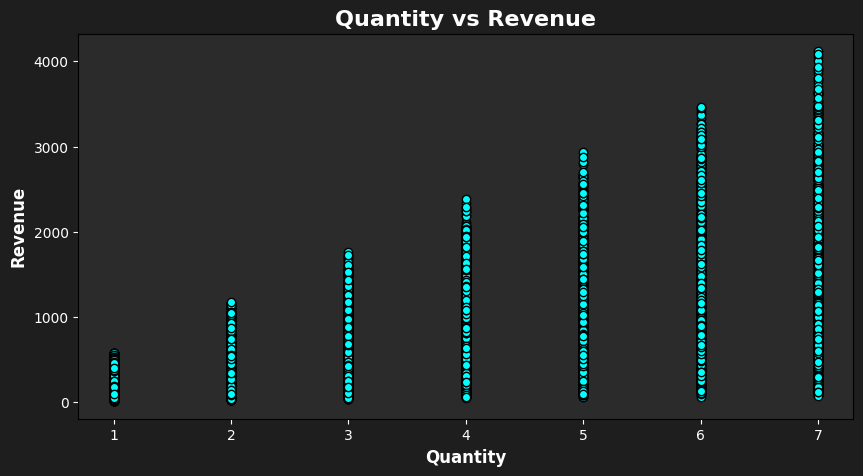

In [9]:
# 8. Scatter Plot: Revenue vs. Quantity
# Question: Is there a relationship between the quantity of products sold and the revenue generated?

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

plt.scatter(df["quantity"], df["revenue"], color="cyan", edgecolor="black")

plt.xlabel("Quantity", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=12, fontweight="bold", color="white")
plt.title("Quantity vs Revenue", fontsize=16, fontweight="bold", color="white")
plt.tick_params(axis="both", colors="white")

plt.savefig("outputs/Quantity_Vs_Revenue.png", dpi=300, bbox_inches="tight")
plt.show()

# As plot shows a positive correlation between quantity and revenue, this means that as the quantity of products sold increases, the revenue also increases. This is expected, as selling more products should lead to higher revenue.

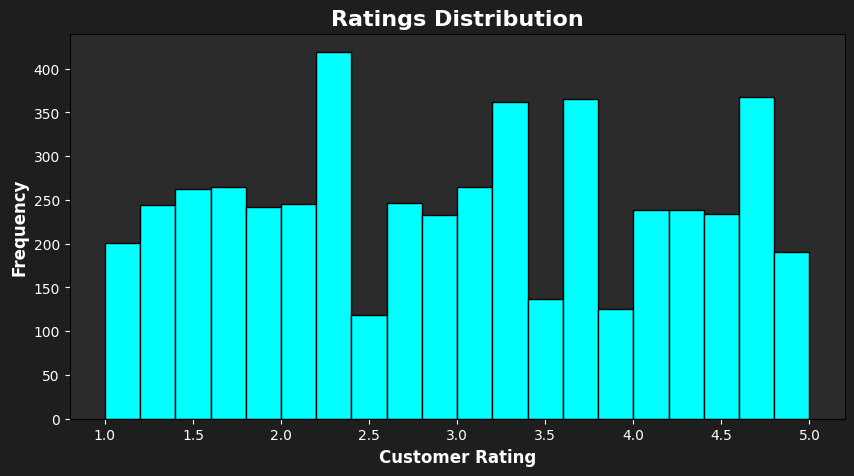

In [10]:
# 9. Histogram: Ratings Distribution
# Question: What is the distribution of customer ratings?

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

plt.hist(df["customer_rating"], bins=20, color="cyan", edgecolor="black")

plt.title("Ratings Distribution", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Customer Rating", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Frequency", fontsize=12, fontweight="bold", color="white")
plt.tick_params(axis="both", colors="white")

plt.savefig("outputs/Ratings_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

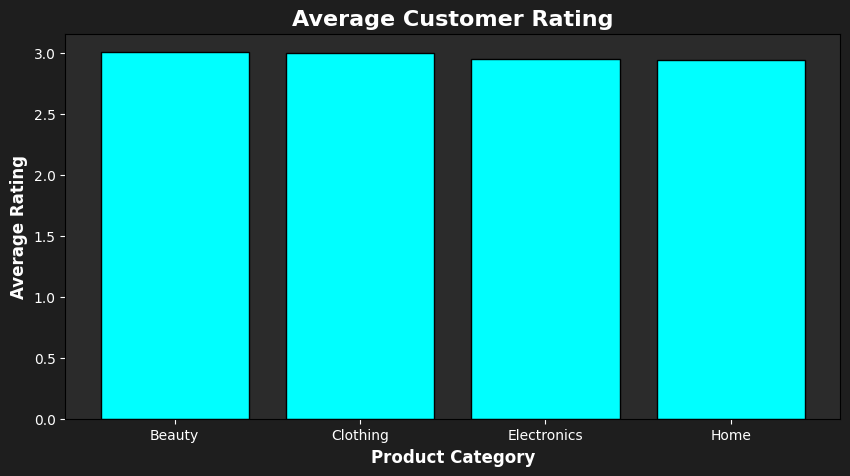

In [11]:
# 10. Bar Plot: Average Customer Rating by Product Category
# Question: What is the average customer rating for each product category?
rating = df.groupby("product_category")["customer_rating"].mean()

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

plt.bar(rating.index, rating.values, color="cyan", edgecolor="black")

plt.title("Average Customer Rating", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Product Category", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Average Rating", fontsize=12, fontweight="bold", color="white")
plt.tick_params(axis="both", colors="white")

plt.savefig("outputs/Average_Customer_Rating.png", dpi=300, bbox_inches="tight")
plt.show()